<a href="https://colab.research.google.com/github/aryaman2603/AryamanGhaisas/blob/main/EDA_CourseProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Loading the dataset using pandas

In [2]:
df = pd.read_csv('supermarket_sales.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


2. Applying basic statistical analysis

In [3]:
print("Dataset Information")
df.info()

print("Summary Statistics")
df.describe()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   998 non-null    object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  999 non-null    object 
 13  cogs                     1000 non-null   float64
 14  gross

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,9.990000e+02,1000.000000,999.000000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.973373
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131501e-14,11.708825,1.719309
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.000000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.500000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.000000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.500000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.000000


3. Handling Missing Data

In [4]:
print("Missing Values in Each Column")

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values in Each Column
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     2
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    1
cogs                       0
gross margin percentage    1
gross income               0
Rating                     1
dtype: int64

Total Missing Values: 5


In [5]:
# Numeric columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Categorical columns
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


/tmp/ipykernel_587/3086819710.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


4. Data Cleaning

In [6]:
# Remove duplicate rows
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

# Standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "_")

print("New Dataset Shape:", df.shape)

df.head()

Duplicate Rows: 0
New Dataset Shape: (1000, 17)


,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax_5%,Total,Date,Time,Payment,cogs,gross_margin_percentage,gross_income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


5. Data Transformation

In [7]:
# Convert Date column into datetime

df["Date"] = pd.to_datetime(df["Date"])

# Create additional useful features

df["Month"] = df["Date"].dt.month_name()

df["Day"] = df["Date"].dt.day_name()

# Convert Time into datetime

df["Time"] = pd.to_datetime(df["Time"]).dt.time

df.head()

/tmp/ipykernel_587/1094908764.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])
/tmp/ipykernel_587/1094908764.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"]).dt.time


,Invoice_ID,Branch,City,Customer_type,Gender,Product_line,Unit_price,Quantity,Tax_5%,Total,Date,Time,Payment,cogs,gross_margin_percentage,gross_income,Rating,Month,Day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,January,Saturday
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6,March,Friday
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,13:23:00,Credit card,324.31,4.761905,16.2155,7.4,March,Sunday
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,January,Sunday
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,February,Friday


6. Univariate analysis with 3 visualizations

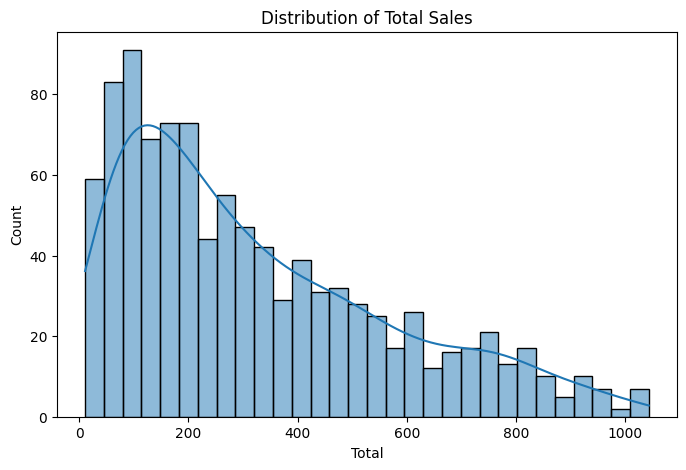

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total"], bins=30, kde=True)

plt.title("Distribution of Total Sales")

plt.show()

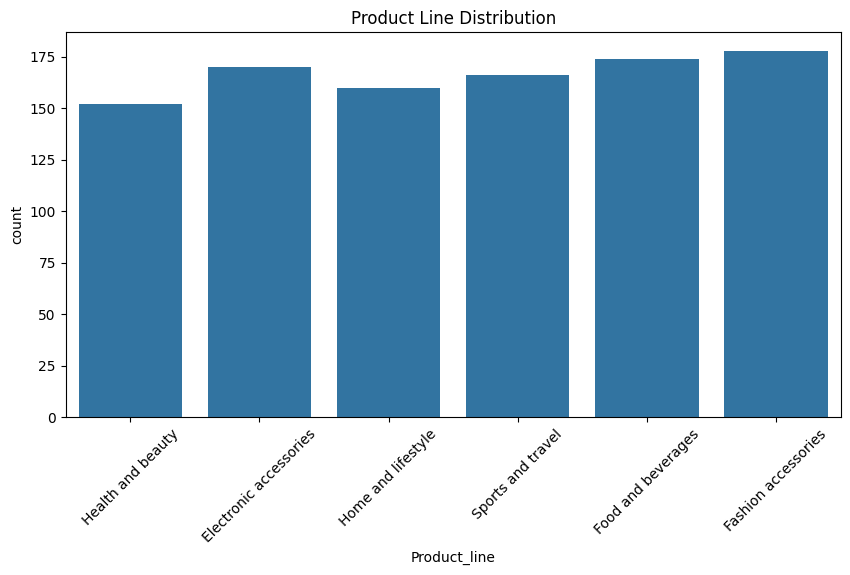

In [9]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Product_line")

plt.xticks(rotation=45)

plt.title("Product Line Distribution")

plt.show()

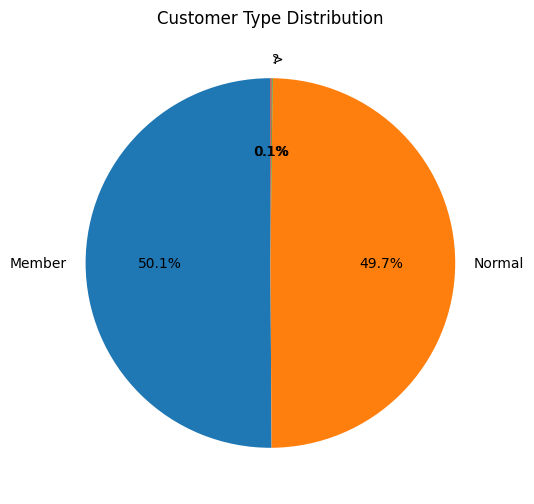

In [10]:
plt.figure(figsize=(6,6))

df["Customer_type"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Customer Type Distribution")

plt.show()

7. Bivariate analysis with 3 visualizations

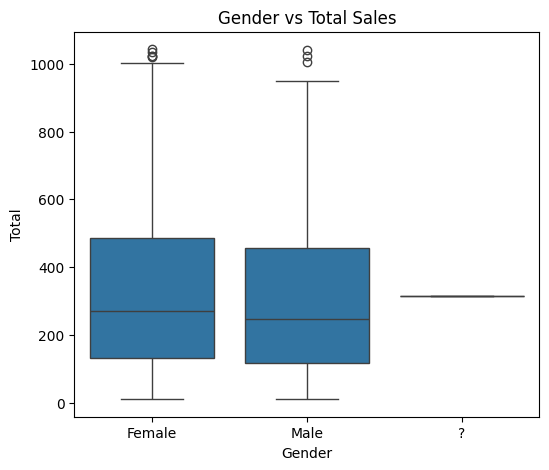

In [11]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x="Gender", y="Total")

plt.title("Gender vs Total Sales")

plt.show()

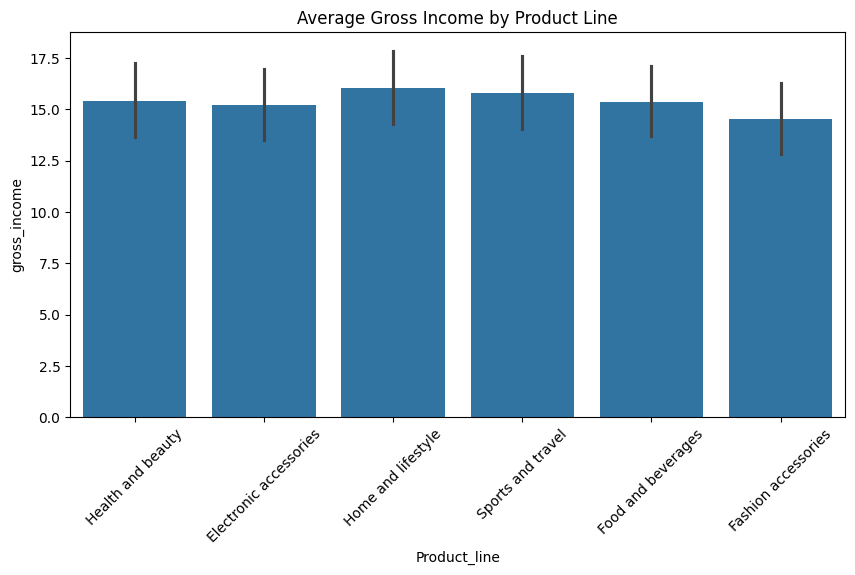

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(data=df, x="Product_line", y="gross_income")

plt.xticks(rotation=45)

plt.title("Average Gross Income by Product Line")

plt.show()

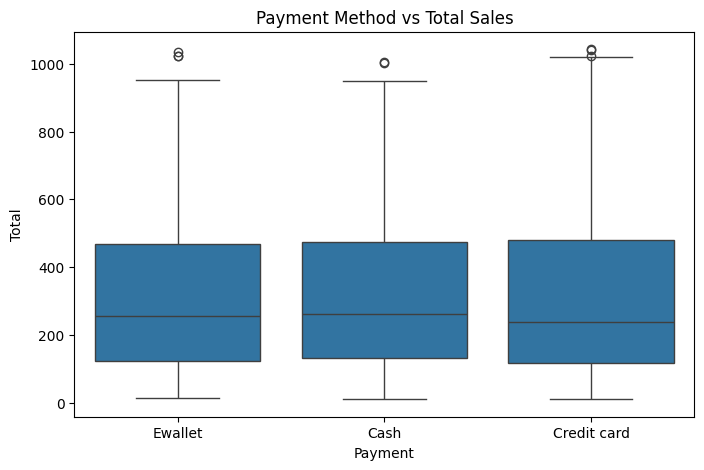

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Payment", y="Total")

plt.title("Payment Method vs Total Sales")

plt.show()

8. Multivariate Analysis with 3 visualizations

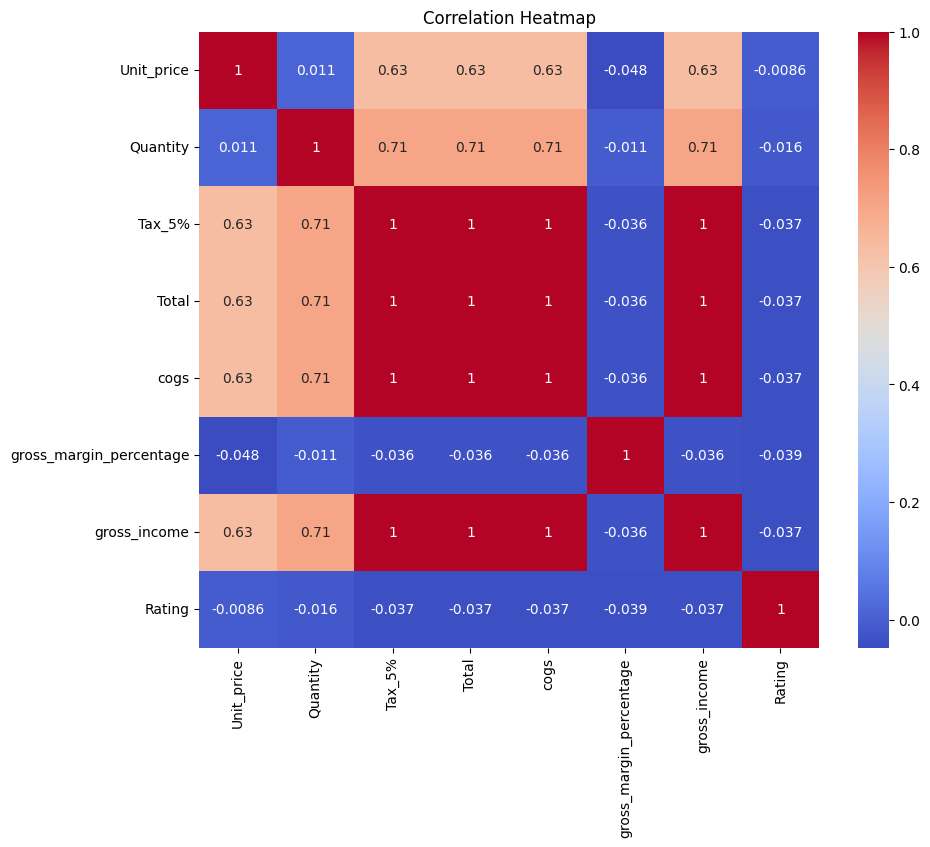

In [14]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

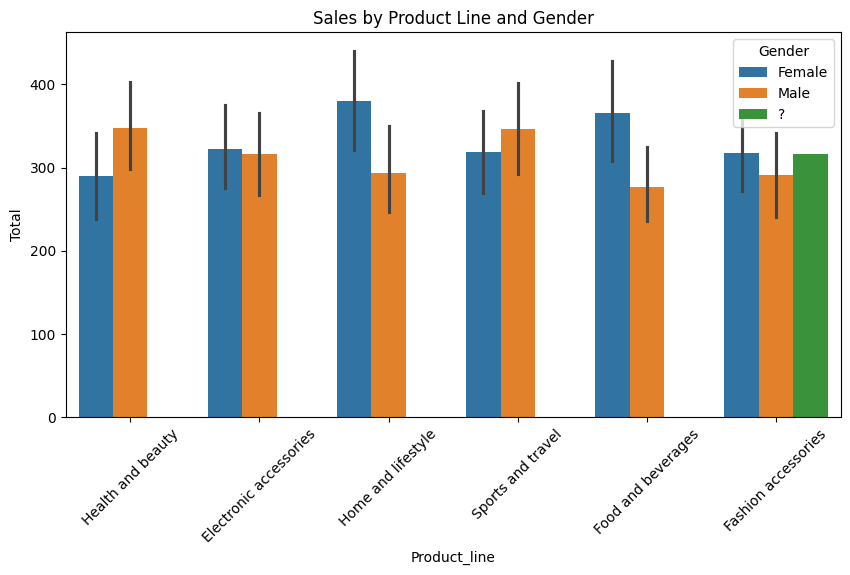

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Product_line",
    y="Total",
    hue="Gender"
)

plt.xticks(rotation=45)

plt.title("Sales by Product Line and Gender")

plt.show()

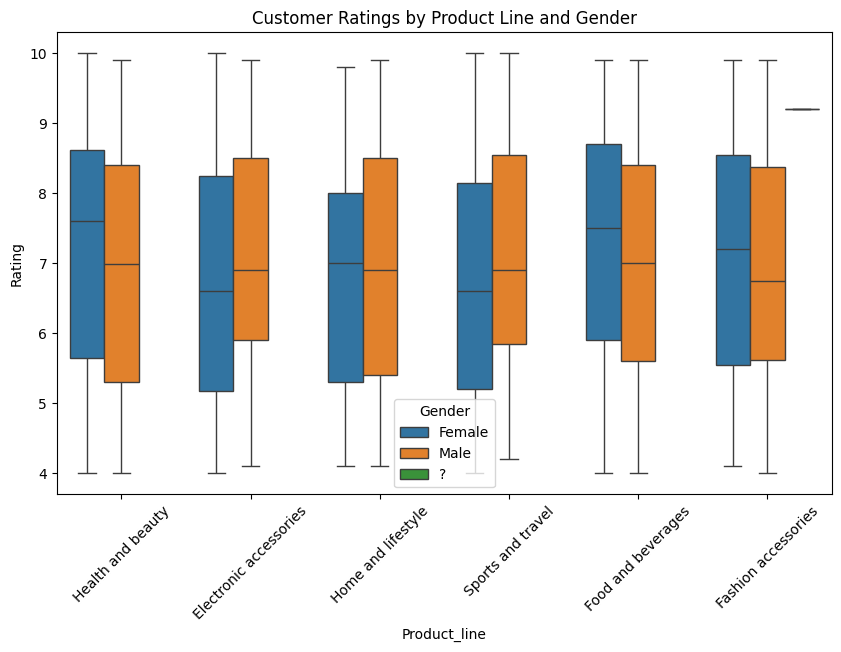

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Product_line",
    y="Rating",
    hue="Gender"
)

plt.xticks(rotation=45)

plt.title("Customer Ratings by Product Line and Gender")

plt.show()